# The comparator panel — the training universe, and what it cannot tell you

Every backtest in this repository runs on this panel. SK Hynix is a forward test and is never
fitted on, so **the panel's coverage is the binding constraint on what any result may claim.**
If you want to disagree with a number in [09](09_tsmc_lab.ipynb) or
[06](06_complexity_ledger.ipynb), start here: this is where the sample is defined and where
every exclusion is declared with its cause.

Three sections, in the order that matters: what is in the panel, what was thrown out and why,
and what the calendar costs to join three legs.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from pipeline.viz import theme, figures
from pipeline.measurement.comparators import coverage_table, calendar_cost
from pipeline.convergence.jorda import REGIME_OF_PAIR, TAXONOMY_RATIFIED, FORWARD_TEST_PAIRS
theme.apply()
cov, cal = coverage_table(), calendar_cost()
print(f"taxonomy ratified {TAXONOMY_RATIFIED} | forward-test instrument: {sorted(FORWARD_TEST_PAIRS)}")

taxonomy ratified 2026-07-29 | forward-test instrument: ['skhy']


## 1. Three regimes, and a fourth category that is not a regime

The taxonomy is **rule-based**: a pair's class is read off a filing, never off a price. That
is the whole point — a classification inferred from how a premium behaves and then used to
explain how premia behave is circular, and this one is not.

- **`one_way_constrained`** — issuance requires the issuer's or a regulator's consent, so
  arbitrage pushes from one side only and the premium is a reflected process.
- **`fungible`** — the two lines convert freely both ways. The control class: π should sit at
  conversion cost with no one-sided drift, and if it does not, the measurement is wrong before
  the economics are interesting.
- **forward test** — SK Hynix, and it is not a regime. It is the instrument the panel exists
  to say something about, and it enters no fit, no cross-validation and no test. A structural
  guard in `pipeline.validation.splitters` fails the run if it ever does.
- **excluded / unreachable** — pairs that were attempted and did not survive. They are listed
  below rather than quietly omitted, because a panel described only by its members overstates
  itself.

In [2]:
cov

,pair,regime,n_obs,first,last,ratio,ratio_confirmed,sample_start,sample_end,restriction_reason
0,pldt,candidate — classification withheld,7454,1994-06-27,2026-07-30,1.00,False,None,None,None
1,auo,excluded,4146,2002-05-23,2019-10-01,10.00,False,None,2019-10-01,AU Optronics filed Form 25 on 2019-09-20 to de...
2,skhy,forward test (never fitted),13,2026-07-10,2026-07-29,0.10,True,None,None,None
3,abev,fungible,4496,2008-01-02,2026-07-28,1.00,False,2008-01-01,None,CONTROL-CLASS RATIO REGIME
4,baba,fungible,1593,2019-11-26,2026-07-28,8.00,False,None,None,None
5,ggb,fungible,6412,2000-01-03,2026-07-28,1.00,False,2000-01-01,None,CONTROL-CLASS RATIO REGIME
6,itub,fungible,4984,2006-01-03,2026-07-28,1.00,False,2006-01-01,None,CONTROL-CLASS RATIO REGIME
7,pbr,fungible,4495,2008-01-02,2026-07-28,2.00,False,2008-01-01,None,CONTROL-CLASS RATIO REGIME
8,vale,fungible,5929,2002-03-21,2026-07-28,1.00,False,None,None,None
9,ase,one_way_constrained,1918,2018-05-02,2026-07-24,2.00,False,2018-05-02,None,2018 ASE Inc -> ASE Technology Holding share e...


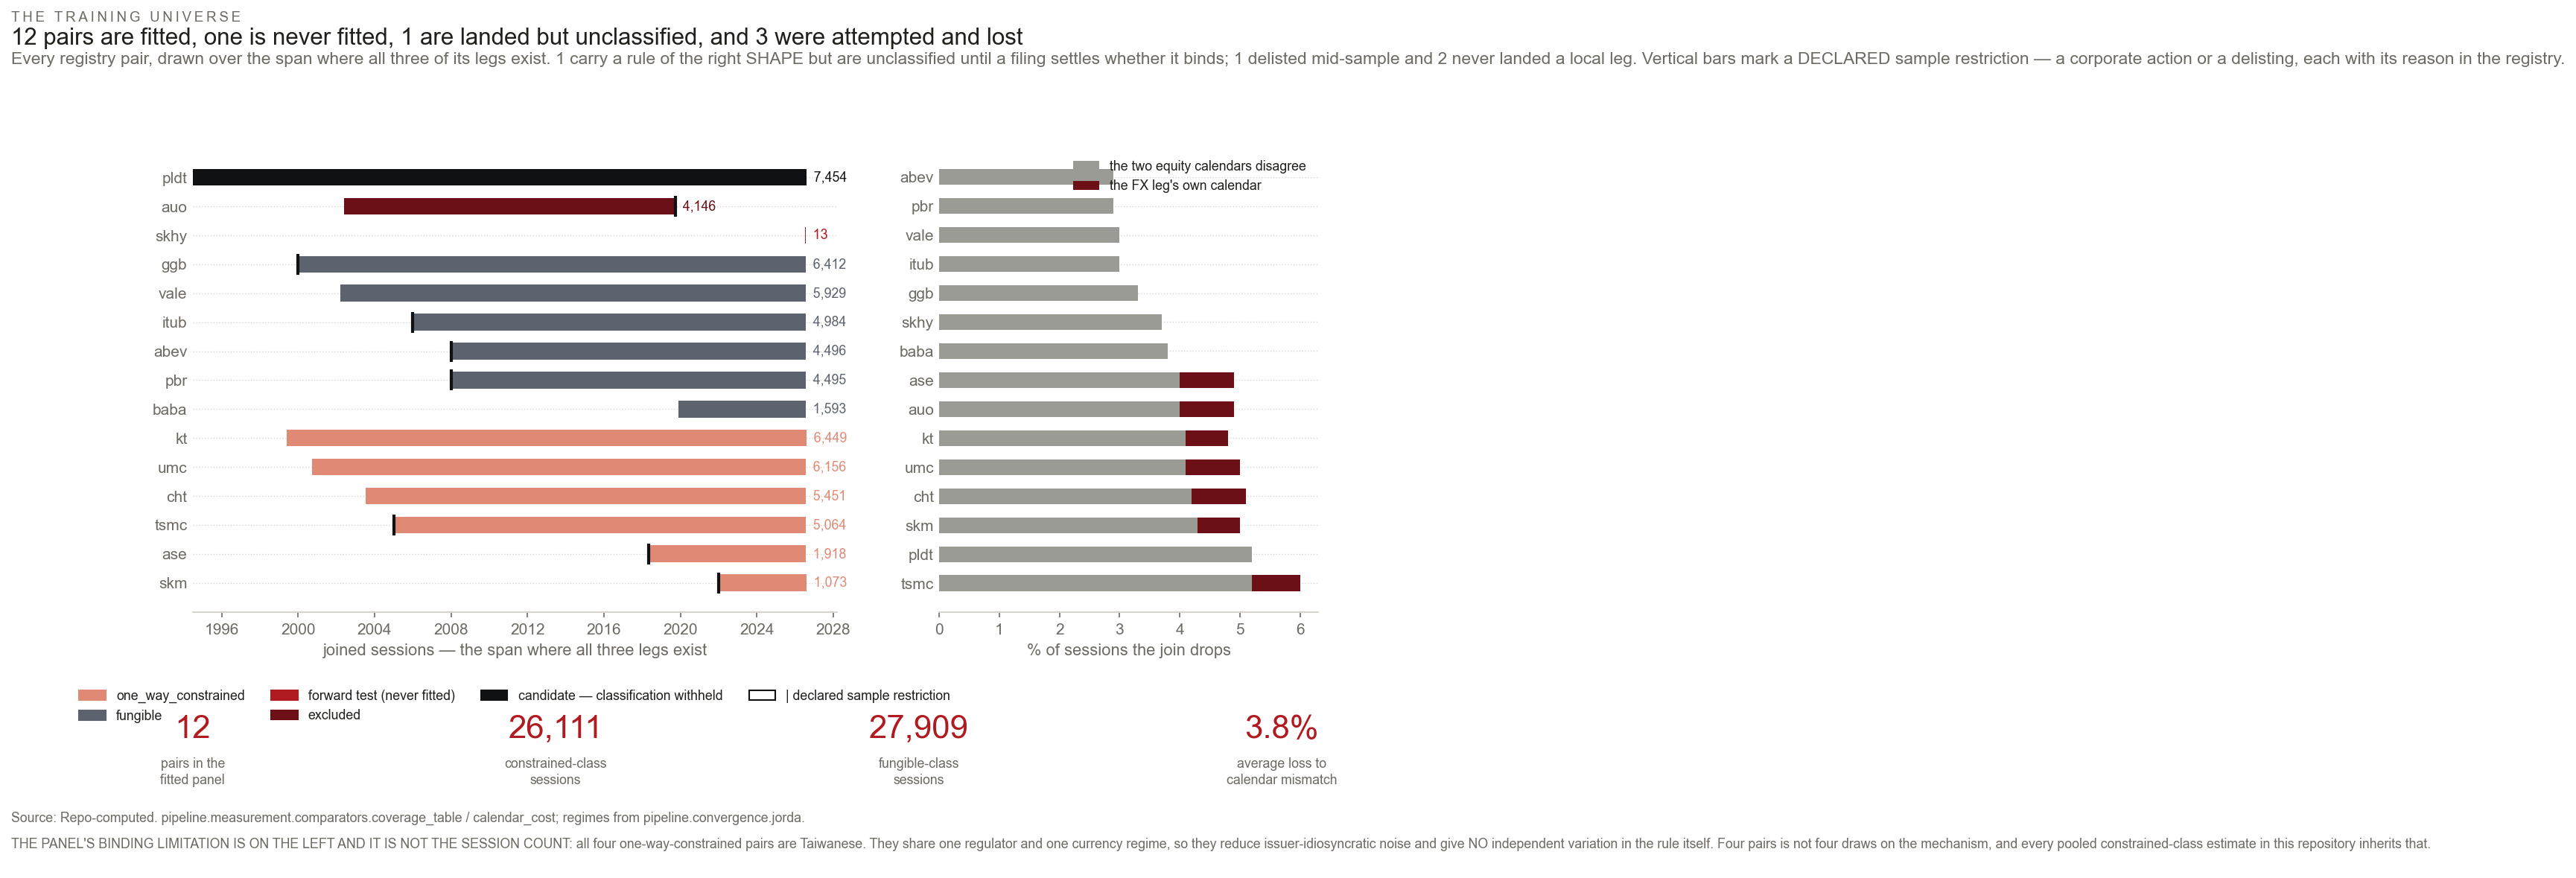

In [3]:
fig, _ = figures.g31_panel_coverage(cov, cal)
fig;

### The panel's binding limitation, stated plainly

**All four one-way-constrained pairs are Taiwanese.** They share one regulator, one currency
regime and one market structure. That makes them excellent for suppressing issuer-idiosyncratic
noise and useless for establishing that the *rule* is what drives the result — four pairs is
not four independent draws on the mechanism.

Every pooled constrained-class estimate in this repository inherits that, and the H6b pooled
test in [07](07_macro_environment.ipynb) says so on its own panel. It is the single most
important sentence on this page, which is why it is not in a footnote.

## 2. Corporate-action QA — every exclusion is declared, with its cause

A premium is a ratio of two raw prices at a fixed share ratio. Any corporate action that moves
one leg without moving the other, or that changes the share count without changing the declared
ratio, injects a step that is **measurement, not economics**. Three of those are in this panel
and each is declared in the registry with the evidence that found it.

In [4]:
restricted = cov[cov.restriction_reason.notna()][
    ["pair", "regime", "first", "last", "sample_start", "sample_end", "restriction_reason"]]
restricted

,pair,regime,first,last,sample_start,sample_end,restriction_reason
1,auo,excluded,2002-05-23,2019-10-01,None,2019-10-01,AU Optronics filed Form 25 on 2019-09-20 to de...
3,abev,fungible,2008-01-02,2026-07-28,2008-01-01,None,CONTROL-CLASS RATIO REGIME
5,ggb,fungible,2000-01-03,2026-07-28,2000-01-01,None,CONTROL-CLASS RATIO REGIME
6,itub,fungible,2006-01-03,2026-07-28,2006-01-01,None,CONTROL-CLASS RATIO REGIME
7,pbr,fungible,2008-01-02,2026-07-28,2008-01-01,None,CONTROL-CLASS RATIO REGIME
9,ase,one_way_constrained,2018-05-02,2026-07-24,2018-05-02,None,2018 ASE Inc -> ASE Technology Holding share e...
12,skm,one_way_constrained,2022-01-03,2026-07-31,2022-01-01,None,"RATIO REGIME BREAK, the ASE failure mode"
13,tsmc,one_way_constrained,2005-01-03,2026-07-24,2005-01-03,None,TSMC's stock-dividend era


**TSMC — the stock-dividend era, excluded from 2005-01-03 back.** Built on raw closes with a
constant 5.0 ratio, the premium averages −55% in 1997 and walks monotonically to roughly zero
by 2005. No arbitrageur left a 55% discount on the table; that is a compounded share-count
artefact. Eleven one-leg-only price jumps above 5σ are detected, **all** between 1997-10-09 and
2002-07-25 and clustered in the June–August ex-dividend season, and **none** in the 24 years
since. Using adjusted closes on both legs is *worse*, not better, because the two legs'
cash-dividend adjustments differ. Notebook 09 re-runs its headline number on the wider
cause-based cut as a curation sensitivity, and the wider sample is **less** favourable — which
is the strongest available answer to the objection that the cut was chosen to flatter.

**ASE — the 2018 share exchange, excluded before 2018-05-02.** The provider splices the
predecessor 2311.TW history in unadjusted: on 2018-04-30 the local close steps 44.5 → 80.3
while the implied ratio steps 4.0 → 2.0, and the constructed premium reaches **+57,714%**. A
ratio spline would not fix it — the price step is 1.80× against a 2.0× ratio change, so
splining injects a spurious ~10% level shift. Before the exchange the two legs are different
securities.

**AU Optronics — delisted, sample ends 2019-10-01.** Form 25 filed 2019-09-20; the ADSs moved
to a Level I OTC programme and later deregistered. The pair is kept in the registry and marked
excluded rather than deleted, so the record shows it was attempted.

**And one restriction that is not a corporate action:** four Brazilian pairs carry a
control-class ratio regime start. That is a declared sample policy, not a defect, and it is
labelled differently for exactly that reason.

## 3. Calendar policy — what it costs to join three legs

π needs an ADR close, a local close and an FX observation **on the same date**. Three markets,
three holiday calendars. The question is how much that costs.

In [5]:
cal[["pair", "overlap_years", "adr_sessions", "local_sessions", "adr_only", "local_only",
     "pct_lost_to_equity_calendars", "pct_lost_to_fx_calendar"]]

,pair,overlap_years,adr_sessions,local_sessions,adr_only,local_only,pct_lost_to_equity_calendars,pct_lost_to_fx_calendar
0,pldt,32.1,8077,7658,621,202,5.2,0.0
1,kt,27.2,6837,6703,345,211,4.1,0.7
2,skm,27.6,6936,6774,373,211,4.3,0.7
3,vale,24.4,6127,6093,198,164,3.0,0.0
4,itub,24.4,6146,6111,199,164,3.0,0.0
5,abev,26.6,6679,6669,198,188,2.9,0.0
6,pbr,26.0,6528,6512,199,183,2.9,0.0
7,ggb,27.4,6888,6783,281,176,3.3,0.0
8,umc,25.8,6499,6454,290,245,4.1,0.9
9,ase,25.8,6490,6417,293,220,4.0,0.9


**Read `dropped_to_join` with care — it is the wrong number for this question.** It compares
against the *longest* leg, so a pair whose local line starts fifteen years after its ADR reports
an enormous "loss" that is really just a short leg. BABA's 5,465 is that artefact, not a
calendar cost. `calendar_cost()` measures **inside the span where all three legs exist**, where
the only thing separating them is which days each market chose to open.

Three findings, all consistent:

1. **The cost is 3–5% of sessions, everywhere.** Remarkably stable across two continents.
2. **The US trades more days than Brazil or Taiwan.** ADR-only days outnumber local-only days
   in every single pair — 413 against 336 for TSMC, 198 against 164 for Vale. Korea and Taiwan
   keep more public holidays than the NYSE.
3. **The FX leg has its own calendar, and the provider decides whether that matters.** The
   Taiwan pairs lose an extra ~0.9% because their FX comes from a FRED series that observes the
   *US* calendar and is therefore absent on days TWSE trades. The Brazilian pairs lose nothing
   to FX because theirs comes from a provider that publishes on local trading days. Same
   construction, different provider, a measurable difference in coverage.

**The policy is intersection, not interpolation.** A missing FX observation is never forward-
filled to rescue a session. Forward-filling a currency across a holiday would put a stale rate
into a price ratio and call the result a premium — a phantom move on every day either market
was shut. Losing 4% of sessions is the cheaper error, and it is the one this repository makes.

---

### What this panel entitles a result to claim

- **Level and dynamics within the constrained class**, with the Taiwan-only caveat attached
  every time.
- **A constrained-versus-fungible contrast**, which is the identifying variation the design
  actually has: two classes, different rules, same construction.
- **Nothing about SK Hynix that was fitted.** Twelve joined sessions, forward test, never in a
  fit — and a structural guard, not a convention, keeps it that way.